## Using CausalML library

CausalML is an open-source Python library developed by Uber for implementing causal inference algorithms using machine learning. It is designed to help data scientists, economists, and policy researchers estimate individualized treatment effects (ITEs) and make data-driven decisions that go beyond correlation.

Unlike traditional predictive modeling, CausalML focuses on answering counterfactual questions—such as what would have happened if we had taken a different action? The library provides a suite of meta-learners (like T-Learner, S-Learner, X-Learner, and R-Learner) that can be easily combined with popular machine learning models such as Random Forests, Gradient Boosted Trees, and Linear Regression.

In today’s post, I’m going to compare the T-Learner implementation in the CausalML package with a custom T-Learner built using Scikit-Learn and Linear Regression. The goal is to provide a clearer understanding of what’s happening under the hood when using CausalML for causal inference.

While CausalML offers a streamlined and powerful API for estimating individual treatment effects, it’s equally important to understand the mechanics behind the scenes. By building the same logic step-by-step using Scikit-Learn, we’ll demystify how the meta-learner works—how models are trained separately for treated and control groups, and how individual treatment effects (ITEs) are derived.

In [1]:
#import the libraries
import polars as pl
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from causalml.inference.meta import BaseTLearner

In [2]:
#The dataset
df = pl.read_csv("dataset.csv")
df.head(5)

age,is_male,race,ownes_house,employment_status,employment_income,non_employment_income,treatment,expenditure
i64,i64,str,i64,i64,f64,f64,i64,f64
18,1,"""Asian""",1,0,0.0,12000.0,0,8156.3
18,0,"""Black""",0,0,0.0,12000.0,0,9915.55
32,0,"""White""",1,1,99157.9,0.0,0,83903.93
33,1,"""Hispanic""",1,0,0.0,10000.0,1,11803.33
43,0,"""White""",0,1,124127.2,0.0,1,123086.25


In [3]:
#encode the categorical variables
race_array = df["race"].to_numpy()
label = LabelEncoder()
race_encoded = label.fit_transform(race_array)

In [4]:
df= df.with_columns(
    pl.Series(race_encoded).alias('race_encoded')
)
df = df.drop("race")
df.head(5)

age,is_male,ownes_house,employment_status,employment_income,non_employment_income,treatment,expenditure,race_encoded
i64,i64,i64,i64,f64,f64,i64,f64,i32
18,1,1,0,0.0,12000.0,0,8156.3,0
18,0,0,0,0.0,12000.0,0,9915.55,1
32,0,1,1,99157.9,0.0,0,83903.93,4
33,1,1,0,0.0,10000.0,1,11803.33,2
43,0,0,1,124127.2,0.0,1,123086.25,4


## T-Learner Model using Scikit-learn library

To begin with, we implement a simple T-Learner using Scikit-Learn’s Linear Regression model. The idea is to divide the dataset into two groups based on the treatment assignment: one group that received the treatment (treatment = 1) and one that did not (treatment = 0). We then train two separate linear regression models—one on the treated group to learn the relationship between covariates and outcomes under treatment, and another on the control group to learn outcomes in the absence of treatment. This mirrors the core structure of the T-Learner, where each subgroup is modeled independently to capture different response behaviors.

In [5]:
treated = df.filter(pl.col("treatment") == 1)
control = df.filter(pl.col("treatment") == 0)

In [6]:
X_treated = treated.drop(["treatment", "expenditure"])
X_control = control.drop(["treatment", "expenditure"])
y_treated = treated["expenditure"]
y_control = control["expenditure"]

In [7]:
lr = LinearRegression()
lr_treated = lr.fit(X_treated, y_treated)
lr = LinearRegression()
lr_control = lr.fit(X_control, y_control)


Once the two models are trained, we use them to generate predictions for the entire dataset, regardless of whether an individual was actually treated or not. That means every individual receives two predicted outcomes: one from the model trained on the treated group (as if they had received the treatment), and one from the model trained on the control group (as if they had not). By taking the difference between these two predictions, we estimate the individual treatment effect (ITE) for each person. This setup allows us to replicate the logic of causal inference using basic regression tools and gain deeper insight into how meta-learners work under the hood.

In [9]:
pred_treated = lr_treated.predict(df.drop(["treatment", "expenditure"]))
pred_control = lr_control.predict(df.drop(["treatment", "expenditure"]))
individual_treatment_effect = pred_treated - pred_control


The individual treatment effect (ITE) is defined as the difference between the predicted outcome under treatment and the predicted outcome under control. It is the causal effect of the treatment on an individual level, which is what we aim to estimate using the T-Learner approach.

In [10]:
df = df.with_columns(
    pl.Series(individual_treatment_effect).alias('individual_treatment_effect')
)
df.head(5)


age,is_male,ownes_house,employment_status,employment_income,non_employment_income,treatment,expenditure,race_encoded,individual_treatment_effect
i64,i64,i64,i64,f64,f64,i64,f64,i32,f64
18,1,1,0,0.0,12000.0,0,8156.3,0,429.704302
18,0,0,0,0.0,12000.0,0,9915.55,1,54.462855
32,0,1,1,99157.9,0.0,0,83903.93,4,1578.028968
33,1,1,0,0.0,10000.0,1,11803.33,2,652.566178
43,0,0,1,124127.2,0.0,1,123086.25,4,1607.833673


## Using CausalML library



Next, we implement the same T-Learner logic using the CausalML library, which simplifies the entire process considerably. Unlike our manual Scikit-Learn approach where we explicitly split the data, train two models, and compute predictions, CausalML handles all of this behind the scenes. It automatically takes care of splitting the data into treatment and control groups, training separate models, and estimating individual treatment effects (ITEs). The only requirement is that the input data must be in NumPy array format, since CausalML does not support Polars or Pandas DataFrames directly. So before fitting the model, we convert our feature matrix, treatment vector, and outcome variable to NumPy arrays. Once that’s done, calling .fit() and .predict() gives us the ITEs with just a few lines of code, making it both efficient and easy to use for causal inference.

In [11]:
df.head()

age,is_male,ownes_house,employment_status,employment_income,non_employment_income,treatment,expenditure,race_encoded,individual_treatment_effect
i64,i64,i64,i64,f64,f64,i64,f64,i32,f64
18,1,1,0,0.0,12000.0,0,8156.3,0,429.704302
18,0,0,0,0.0,12000.0,0,9915.55,1,54.462855
32,0,1,1,99157.9,0.0,0,83903.93,4,1578.028968
33,1,1,0,0.0,10000.0,1,11803.33,2,652.566178
43,0,0,1,124127.2,0.0,1,123086.25,4,1607.833673


In [12]:
T_learner = BaseTLearner(learner=LinearRegression())

In [13]:
# Convert Polars DataFrame to NumPy arrays
X = df.drop(["treatment", "expenditure","individual_treatment_effect"]).to_numpy()
t = df["treatment"].to_numpy()
y = df["expenditure"].to_numpy()

In [14]:
# Fit the T-Learner
T_learner.fit(X=X, treatment=t, y=y)

# Prepare feature matrix for prediction (must match training format)
X_pred = df.drop(["treatment", "expenditure", "individual_treatment_effect"]).to_numpy()

# Predict individual treatment effects (ITE)
ite = T_learner.predict(X=X_pred)


In [15]:
df = df.with_columns(
    pl.Series(ite).alias('individual_treatment_effect_CausalML')
)
df.head()

age,is_male,ownes_house,employment_status,employment_income,non_employment_income,treatment,expenditure,race_encoded,individual_treatment_effect,individual_treatment_effect_CausalML
i64,i64,i64,i64,f64,f64,i64,f64,i32,f64,"array[f64, 1]"
18,1,1,0,0.0,12000.0,0,8156.3,0,429.704302,[429.704302]
18,0,0,0,0.0,12000.0,0,9915.55,1,54.462855,[54.462855]
32,0,1,1,99157.9,0.0,0,83903.93,4,1578.028968,[1578.028968]
33,1,1,0,0.0,10000.0,1,11803.33,2,652.566178,[652.566178]
43,0,0,1,124127.2,0.0,1,123086.25,4,1607.833673,[1607.833673]


### Check if both values match

At this point, we have obtained two sets of individual treatment effect (ITE) estimates—one from our Scikit-Learn-based T-Learner and the other from the CausalML implementation. To ensure that both approaches are producing consistent results, I’ll perform a few checks. First, I’ll do a row-wise subtraction between the two ITE arrays and compute the sum of all differences; if the implementations are equivalent, the result should be close to zero. Next, I’ll compare key summary statistics—including the mean, standard deviation, minimum, and maximum values—of both ITE arrays to confirm they’re statistically aligned. Finally, I’ll visualize both sets of results using histograms to check that their distribution shapes match. These checks provide a strong diagnostic to validate that the internal logic of CausalML aligns with the manual Scikit-Learn implementation.

In [69]:
sum((df["individual_treatment_effect"] - df["individual_treatment_effect_CausalML"]))

""
f64
0.000007


In [70]:
import numpy as np

mean_ite = np.mean(individual_treatment_effect)
std_ite = np.std(individual_treatment_effect)
min_ite = np.min(individual_treatment_effect)
max_ite = np.max(individual_treatment_effect)

print("mean: " , mean_ite, "SD: ",std_ite, "Min: ",min_ite, "Max: " ,max_ite)

mean:  1031.8225482654943 SD:  678.3552719488672 Min:  -29.641057825252574 Max:  3583.078880358924


In [ ]:
mean_ite = np.mean(ite)
std_ite = np.std(ite)
min_ite = np.min(ite)
max_ite = np.max(ite)

print("mean: " , mean_ite, "SD: ",std_ite, "Min: ",min_ite, "Max: " ,max_ite)

mean:  1031.8225482653581 SD:  678.3552719488529 Min:  -29.641057825554526 Max:  3583.0788803588657


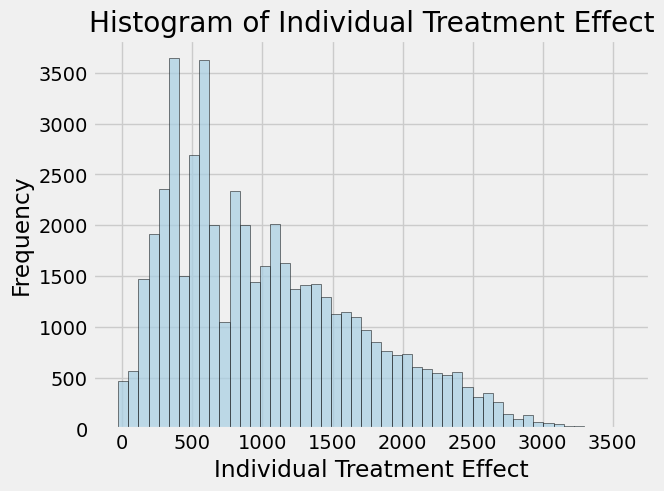

In [72]:
import matplotlib.pyplot as plt

plt.hist(individual_treatment_effect, bins=50, edgecolor='k', alpha=0.7)
plt.title('Histogram of Individual Treatment Effect')
plt.xlabel('Individual Treatment Effect')
plt.ylabel('Frequency')
plt.show()

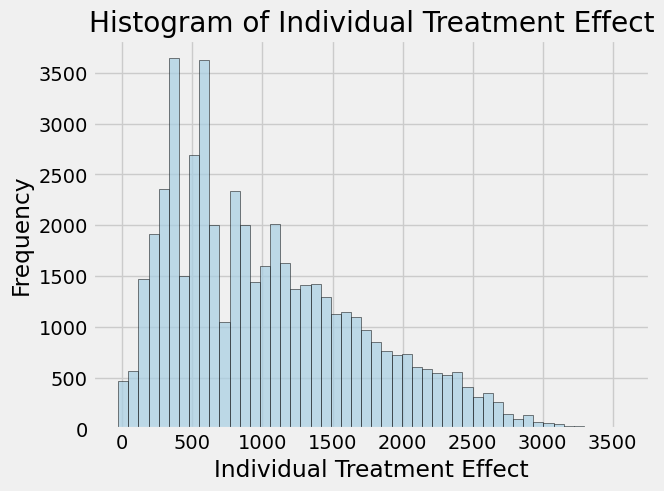

In [73]:
import matplotlib.pyplot as plt

plt.hist(ite, bins=50, edgecolor='k', alpha=0.7)
plt.title('Histogram of Individual Treatment Effect')
plt.xlabel('Individual Treatment Effect')
plt.ylabel('Frequency')
plt.show()

The results from both the Scikit-Learn implementation and the CausalML T-Learner are nearly identical, confirming that both approaches follow the same underlying logic for estimating individual treatment effects. The row-wise differences are negligible, and the summary statistics and histograms show almost perfect alignment. This validates the correctness of CausalML’s internal modeling.

While building the T-Learner manually using Scikit-Learn helps deepen our understanding of how treatment and control models work, the CausalML package offers a much more efficient alternative. It abstracts away the boilerplate steps—like splitting data, fitting two models, and calculating treatment effects—into a clean, well-structured API. This not only saves time but also helps keep your codebase cleaner and easier to maintain, especially for larger projects involving complex causal inference workflows.

